In [5]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [6]:
data24_candidates = pd.read_pickle('data24_candidates.pkl')

data_up = data24_candidates.query('MAGFIELD == True')
data_down = data24_candidates.query('MAGFIELD == False')

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization

  RooFitResult: minimized FCN value: 88415.2, estimated distance to minimum: 1.99847e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESS

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


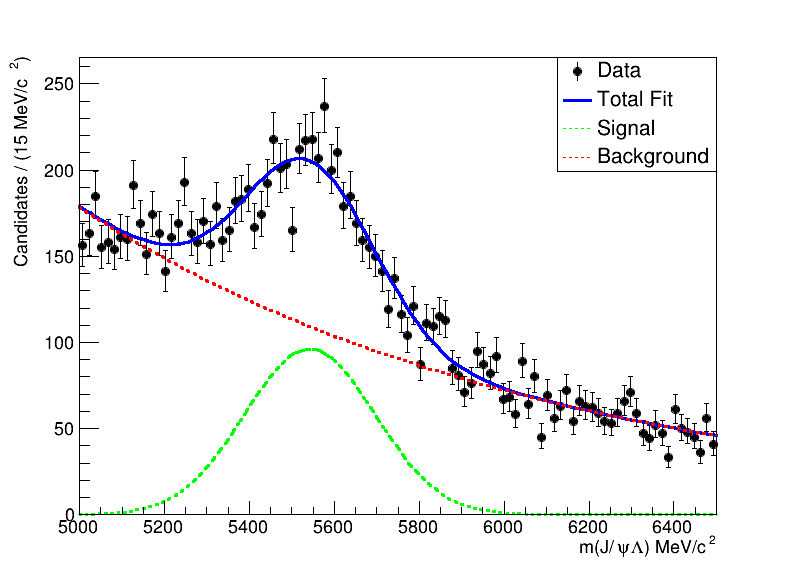

In [7]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas  abs(data24_magup['alpha_combined']) > 0.45) & 
filtered_mass = data_up['Lb_MASS']

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

# Construye el modelo de señal Gaussiano
signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# Define el parámetro para el fondo exponencial
lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

# Construye el modelo de fondo exponencial
background = ROOT.RooExponential('background', 'background', x, lambda_bg)

# Realiza el ajuste del fondo
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construye un modelo combinado de señal y fondo
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Realiza el ajuste total
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Imprime los resultados del ajuste
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo combinado
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajusta el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajusta el estilo de la línea de la leyenda para el fondo a rojo y discontinua
background_line = ROOT.TLine()
background_line.SetLineColor(ROOT.kRed)
background_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(background_line, "Background", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Opcional: imprime las definiciones para verificar
x.Print()
sigmean.Print()
sigwidth.Print()
lambda_bg.Print()
nsig.Print()
nbkg.Print()
model.Print()


[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal,background)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization

  RooFitResult: minimized FCN value: 121141, estimated distance to minimum: 7.09969e-07
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


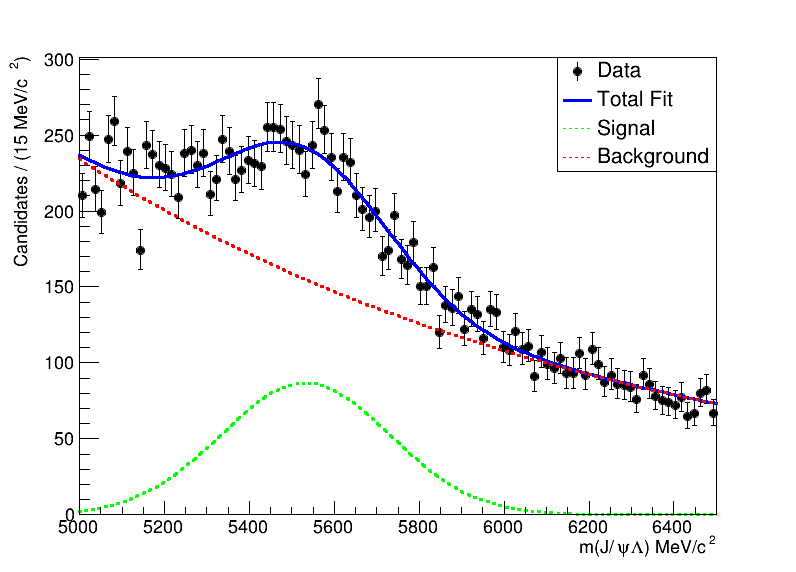

In [8]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas  abs(data24_magup['alpha_combined']) > 0.45) & 
filtered_mass = data_down['Lb_MASS']

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 5000, 6500)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 5600, 5500, 5650)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 120, 100, 300)

# Construye el modelo de señal Gaussiano
signalModel = ROOT.RooGaussian('signal', 'signal', x, sigmean, sigwidth)

# Define el parámetro para el fondo exponencial
lambda_bg = ROOT.RooRealVar('lambda_bg', 'slope', -0.001, -1.0, 0.0)

# Construye el modelo de fondo exponencial
background = ROOT.RooExponential('background', 'background', x, lambda_bg)

# Realiza el ajuste del fondo
background_fit_result = background.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Construye un modelo combinado de señal y fondo
nsig = ROOT.RooRealVar('nsig', 'nsig', 1000, 100., 20000)
nbkg = ROOT.RooRealVar('nbkg', 'nbkg', 400, 100., 20000)
model = ROOT.RooAddPdf('model', 'model', ROOT.RooArgList(signalModel, background), ROOT.RooArgList(nsig, nbkg))

# Realiza el ajuste total
total_fit_result = model.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Imprime los resultados del ajuste
background_fit_result.Print()
signal_fit_result.Print()
total_fit_result.Print()

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo combinado
data_list.plotOn(xframe)
model.plotOn(xframe)
model.plotOn(xframe, ROOT.RooFit.Components('background'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(xframe, ROOT.RooFit.Components('signal'), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(J/#psi#Lambda) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)

# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")
legend.AddEntry(xframe.findObject("model_Norm[x]"), "Total Fit", "l")

# Ajusta el estilo de la línea de la leyenda para la señal a verde y discontinua
signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kGreen)
signal_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(signal_line, "Signal", "l")

# Ajusta el estilo de la línea de la leyenda para el fondo a rojo y discontinua
background_line = ROOT.TLine()
background_line.SetLineColor(ROOT.kRed)
background_line.SetLineStyle(ROOT.kDashed)
legend.AddEntry(background_line, "Background", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
canvas.Draw()
legend.Draw()

# Opcional: imprime las definiciones para verificar
x.Print()
sigmean.Print()
sigwidth.Print()
lambda_bg.Print()
nsig.Print()
nbkg.Print()
model.Print()


Ajuste con doble crystal ball


===== Parámetros del Ajuste =====
sigmean: 1117.356225886282 ± 0.2211405435451752
sigwidth: 14.906872036282754 ± 0.15927773600402784
alpha1: -0.5000001648752743 ± 0.0045560056181583874
n1: 1.822115100841181 ± 0.02033393230689562
alpha2: 3.425971071360466 ± 5.666152163533072
n2: 9.485154101281513 ± 50.53759595551683
frac: 0.9999999988914601 ± 0.004297055002459027

===== Estadísticas del Ajuste =====
Chi2/Ndof: 1.474191699683162/93
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb_left,cb_right)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


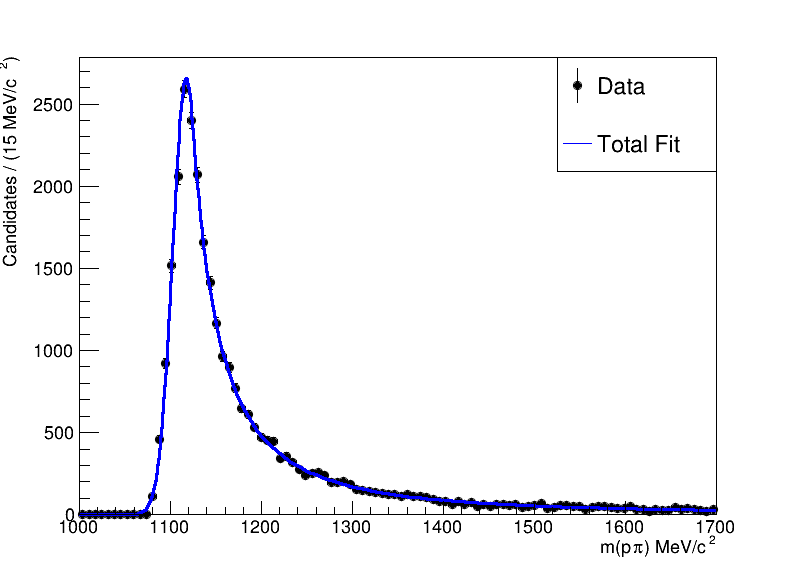

In [11]:
import ROOT
import pandas as pd

# Filtra los datos según las condiciones especificadas
filtered_mass = data24_candidates['L_MASS']

# Convierte la Serie de pandas filtrada a un RooDataSet
x = ROOT.RooRealVar('x', 'x', 1000, 1700)
data_list = ROOT.RooDataSet('data', 'data', ROOT.RooArgSet(x))
for mass in filtered_mass:
    x.setVal(mass)
    data_list.add(ROOT.RooArgSet(x))

# Define los parámetros para la señal (izquierda y derecha) usando CrystalBallShape
sigmean = ROOT.RooRealVar('sigmean', 'sigmean', 1115, 1100, 1150)
sigwidth = ROOT.RooRealVar('sigwidth', 'sigwidth', 10, 1, 100)

# Parámetros de la cola izquierda
alpha1 = ROOT.RooRealVar('alpha1', 'alpha1', -1.5, -10.0, -0.5)
n1 = ROOT.RooRealVar('n1', 'n1', 10, 0.1, 10)

# Parámetros de la cola derecha
alpha2 = ROOT.RooRealVar('alpha2', 'alpha2', 1.5, 0.5, 10.0)
n2 = ROOT.RooRealVar('n2', 'n2', 2, 0.1, 100)

# Crear dos Crystal Ball: uno para la cola izquierda y otro para la derecha
cb_left = ROOT.RooCBShape('cb_left', 'Crystal Ball Left Tail', x, sigmean, sigwidth, alpha1, n1)
cb_right = ROOT.RooCBShape('cb_right', 'Crystal Ball Right Tail', x, sigmean, sigwidth, alpha2, n2)

# Cambia la fracción para dar más peso a la función de cola derecha
frac = ROOT.RooRealVar('frac', 'frac', 0.9, 0.0, 1.0)
signalModel = ROOT.RooAddPdf('signal', 'Double Crystal Ball', cb_left, cb_right, frac)

# Realiza el ajuste de la señal
signal_fit_result = signalModel.fitTo(data_list, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Minimizer("Minuit"), ROOT.RooFit.Save())

# Extrae y muestra los resultados de ajuste
print("\n===== Parámetros del Ajuste =====")
print(f"sigmean: {sigmean.getVal()} ± {sigmean.getError()}")
print(f"sigwidth: {sigwidth.getVal()} ± {sigwidth.getError()}")
print(f"alpha1: {alpha1.getVal()} ± {alpha1.getError()}")
print(f"n1: {n1.getVal()} ± {n1.getError()}")
print(f"alpha2: {alpha2.getVal()} ± {alpha2.getError()}")
print(f"n2: {n2.getVal()} ± {n2.getError()}")
print(f"frac: {frac.getVal()} ± {frac.getError()}")

# Muestra algunas estadísticas del ajuste
xframe = x.frame()
data_list.plotOn(xframe)
signalModel.plotOn(xframe)
chi2 = xframe.chiSquare()
ndof = xframe.GetNbinsX() - signal_fit_result.floatParsFinal().getSize()
print("\n===== Estadísticas del Ajuste =====")
print(f"Chi2/Ndof: {chi2}/{ndof}")

# Crea un RooPlot para dibujar
xframe = x.frame()

# Dibuja los datos y el modelo de señal
data_list.plotOn(xframe)
signalModel.plotOn(xframe, ROOT.RooFit.LineColor(ROOT.kBlue)) 


# Configura los títulos de los ejes
xframe.SetTitle("")
xframe.SetXTitle("m(p#pi) MeV/c^{2}")
xframe.SetYTitle("Candidates / (15 MeV/c^{2})")

# Crea una leyenda
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
# Ajusta el estilo de los puntos de la leyenda a círculos
data_marker = ROOT.TMarker()
data_marker.SetMarkerStyle(ROOT.kFullCircle)
legend.AddEntry(data_marker, "Data", "pe")

signal_line = ROOT.TLine()
signal_line.SetLineColor(ROOT.kBlue)
legend.AddEntry(signal_line, "Total Fit", "l")

# Dibuja el gráfico
canvas = ROOT.TCanvas('canvas', 'Fit Plot', 800, 600)
xframe.Draw()
legend.Draw()
canvas.Draw()
